# Model in Linear Regression + Parameters in Linear Regression

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
X = np.array([1,3,4,6,7]) # years of experience
y = np.array([15, 35, 45,65,75]) # salary in thousands

<Axes: >

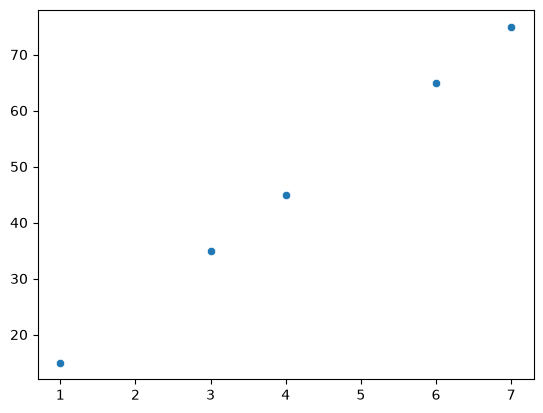

In [52]:
sns.scatterplot(x=X, y=y)

In [53]:
def make_predection(X, y,w, b): 
    m = X.shape[0]
    pred_list = np.zeros((m))

    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

[0. 0. 0. 0. 0.]


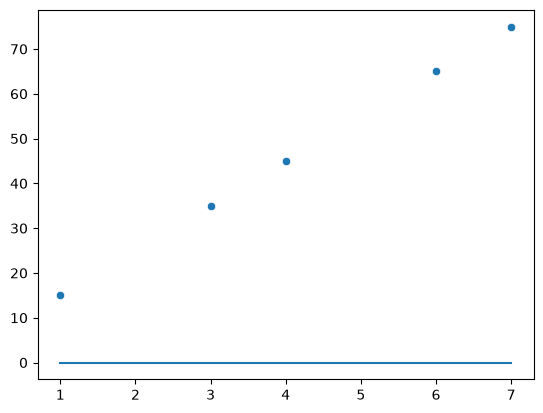

In [54]:
predictions = make_predection(X,y,0,0)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)

[1. 3. 4. 6. 7.]


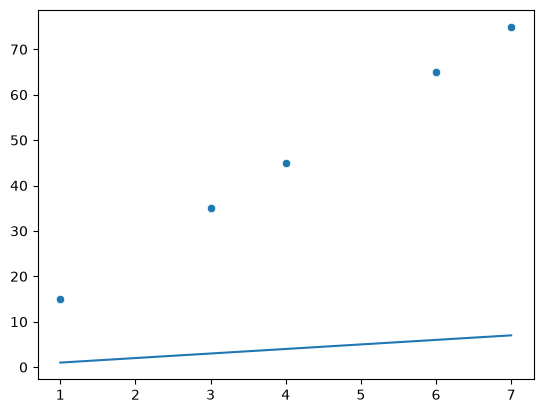

In [55]:
predictions = make_predection(X,y,w=1, b=0)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)

[15. 35. 45. 65. 75.]


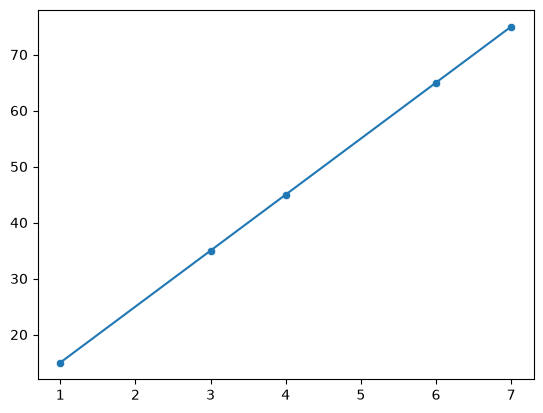

In [56]:
predictions = make_predection(X,y,w=10, b=5)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)

# Implementation of cost function

In [57]:
def compute_cost(X, y, w,b):
    m = X.shape[0] # numbers of data points

    cost = 0.0 
    
    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared

    cost = cost / (2 * m)
    return cost

[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost:1332.5, for w=0.0 and b=0.0')

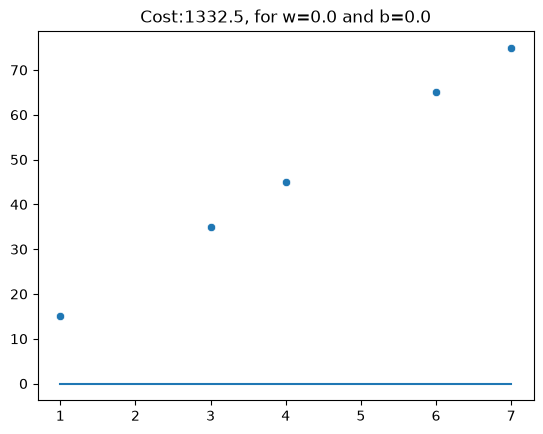

In [58]:
w= 0.0
b= 0.0

predictions = make_predection(X,y,w=w, b=b)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)
plt.title(f'Cost:{compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}')

[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost:1100.6, for w=1.0 and b=0.0')

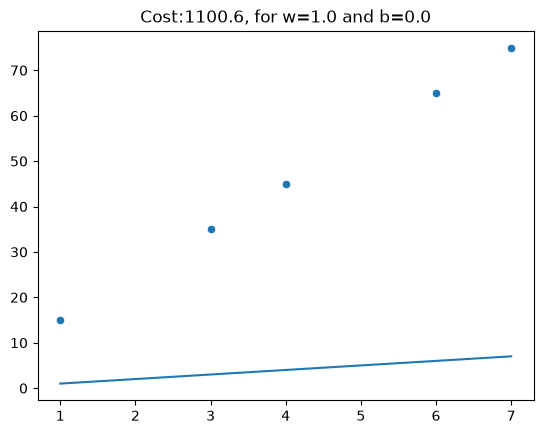

In [59]:
w= 1.0
b= 0.0

predictions = make_predection(X,y,w=w, b=b)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)
plt.title(f'Cost:{compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}')

[ 3.  7.  9. 13. 15.]


Text(0.5, 1.0, 'Cost:852.8, for w=2.0 and b=1.0')

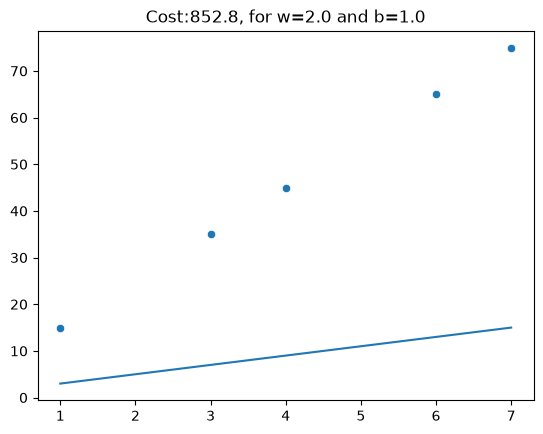

In [60]:
w= 2.0
b= 1.0

predictions = make_predection(X,y,w=w, b=b)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)
plt.title(f'Cost:{compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}')

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost:0.0, for w=10.0 and b=5.0')

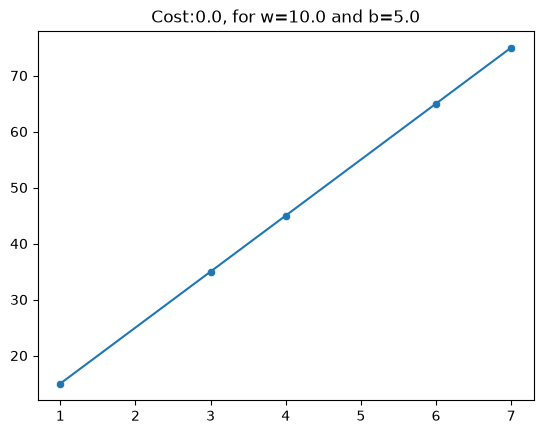

In [61]:
w= 10.0
b= 5.0

predictions = make_predection(X,y,w=w, b=b)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)
plt.title(f'Cost:{compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}')

# Idea of Minimizing the cost function

Text(0, 0.5, 'cost - J(w,b)')

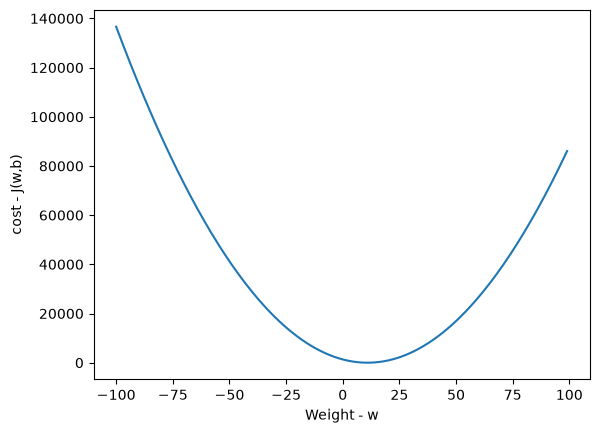

In [62]:
w =[]
cost =[]

# weights -100 to 100
for i in range(-100, 100):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i)
    cost.append(cost_i)

plt.plot(w,cost) 
plt.xlabel('Weight - w')
plt.ylabel('cost - J(w,b)')  

# Idea of Gradient Descent

 # Calcualation of Gradient

In [63]:
def calculate_gradient(X,y,w,b):
    m = X.shape[0] # numbers of data points

    dj_dw = 0.0
    dj_db = 0.0 

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    dj_dw = dj_dw /m
    dj_db = dj_db /m    

    return dj_dw, dj_db

In [64]:
calculate_gradient(X,y,w=3,b=0)

(np.float64(-176.4), np.float64(-34.4))

# Applying Gradient Descent to minimize cost and Final Prediction

In [65]:
def gradient_descent(X, y, w_input , b_input, max_iter  ,alpha= 0.01):

    w = w_input
    b = b_input

    cost_memo = []
    iteration =[]

    for i in range(max_iter):
        dj_dw , dj_db = calculate_gradient(X,y,w,b)

        # update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X,y, w,b)

        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0 :
            print(f'iteration :{i} w:{w:0.4f} ,b:{b:0.4f} , dj_dw:{dj_dw:0.4f}, dj_db:{dj_db:0.4f}, cost: {cost:0.4f}')

    return w,b, cost_memo, iteration

In [66]:
w_final, b_final, memo, iter = gradient_descent(X, y, w_input=0 , b_input = 0, max_iter = 10000  ,alpha= 0.01)

iteration :0 w:2.4300 ,b:0.4700 , dj_dw:-243.0000, dj_db:-47.0000, cost: 790.3717
iteration :100 w:10.4659 ,b:2.5593 , dj_dw:0.0926, dj_db:-0.4848, cost: 0.6120
iteration :200 w:10.3821 ,b:2.9986 , dj_dw:0.0759, dj_db:-0.3976, cost: 0.4115
iteration :300 w:10.3133 ,b:3.3588 , dj_dw:0.0622, dj_db:-0.3260, cost: 0.2767
iteration :400 w:10.2569 ,b:3.6542 , dj_dw:0.0510, dj_db:-0.2673, cost: 0.1861
iteration :500 w:10.2107 ,b:3.8965 , dj_dw:0.0418, dj_db:-0.2192, cost: 0.1251
iteration :600 w:10.1727 ,b:4.0951 , dj_dw:0.0343, dj_db:-0.1798, cost: 0.0841
iteration :700 w:10.1416 ,b:4.2580 , dj_dw:0.0281, dj_db:-0.1474, cost: 0.0566
iteration :800 w:10.1162 ,b:4.3915 , dj_dw:0.0231, dj_db:-0.1209, cost: 0.0380
iteration :900 w:10.0952 ,b:4.5010 , dj_dw:0.0189, dj_db:-0.0991, cost: 0.0256
iteration :1000 w:10.0781 ,b:4.5909 , dj_dw:0.0155, dj_db:-0.0813, cost: 0.0172
iteration :1100 w:10.0640 ,b:4.6645 , dj_dw:0.0127, dj_db:-0.0666, cost: 0.0116
iteration :1200 w:10.0525 ,b:4.7249 , dj_dw:0.0

10.00000000137122 4.999999992816854
[14.99999999 35.         45.         65.         75.        ]


Text(0.5, 1.0, 'Cost:5.300876935637457e-18, for w=10.00000000137122 and b=4.999999992816854')

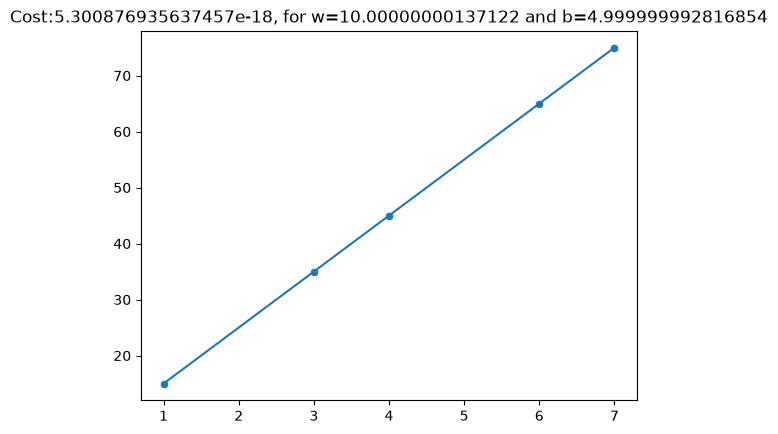

In [80]:
print(w_final,b_final)

predictions = make_predection(X,y,w=w_final, b=b_final)
print(predictions)

sns.scatterplot(x = X, y = y)
plt.plot(X,predictions)
plt.title(f'Cost:{compute_cost(X,y,w=w_final,b=b_final)}, for w={w_final} and b={b_final}')

In [84]:
# jar 2 bochor er experience ase tar salary 

x = 2

prediction = w_final * x + b_final

print(prediction)

24.999999995559293
